릿지 회귀

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn. linear_model import Ridge
from sklearn.model_selection import cross_val_score,train_test_split 
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# 보스턴 데이터 직접 로드 (Raw URL 이용)
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# 데이터 구조상 홀수 줄과 짝수 줄을 결합
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# 컬럼명 설정
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# DataFrame 변환
bostonDF = pd.DataFrame(data, columns=feature_names)
bostonDF['PRICE'] = target

# X, y 분리
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1)

#학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

#alpha=10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha = 10)
#교차검증 수행
neg_mse_scores=cross_val_score(ridge,X_data,y_target,scoring="neg_mean_squared_error",cv=5)
#음수 MSE를 RMSE로 변환
rmse_scores=np.sqrt(-1*neg_mse_scores)
#5개 폴드의 평균 RMSE 계산
avg_rmse=np.mean(rmse_scores)

In [3]:
#릿지에 사용될 alpha 파라미터의 값을 정의
alphas=[0,0.1,1,10,100]

#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge=Ridge(alpha=alpha)

    #cross_val_score를 이용해 5폴드의 평균rmse 계산
    neg_mse_scores=cross_val_score(ridge,X_data,y_target,scoring="neg_mean_squared_error",cv=5)
    avg_rmse=np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha{0}일때 5 folds의 평균 RMSE:{1:.3f}'.format(alpha,avg_rmse))

alpha0일때 5 folds의 평균 RMSE:5.829
alpha0.1일때 5 folds의 평균 RMSE:5.788
alpha1일때 5 folds의 평균 RMSE:5.653
alpha10일때 5 folds의 평균 RMSE:5.518
alpha100일때 5 folds의 평균 RMSE:5.330


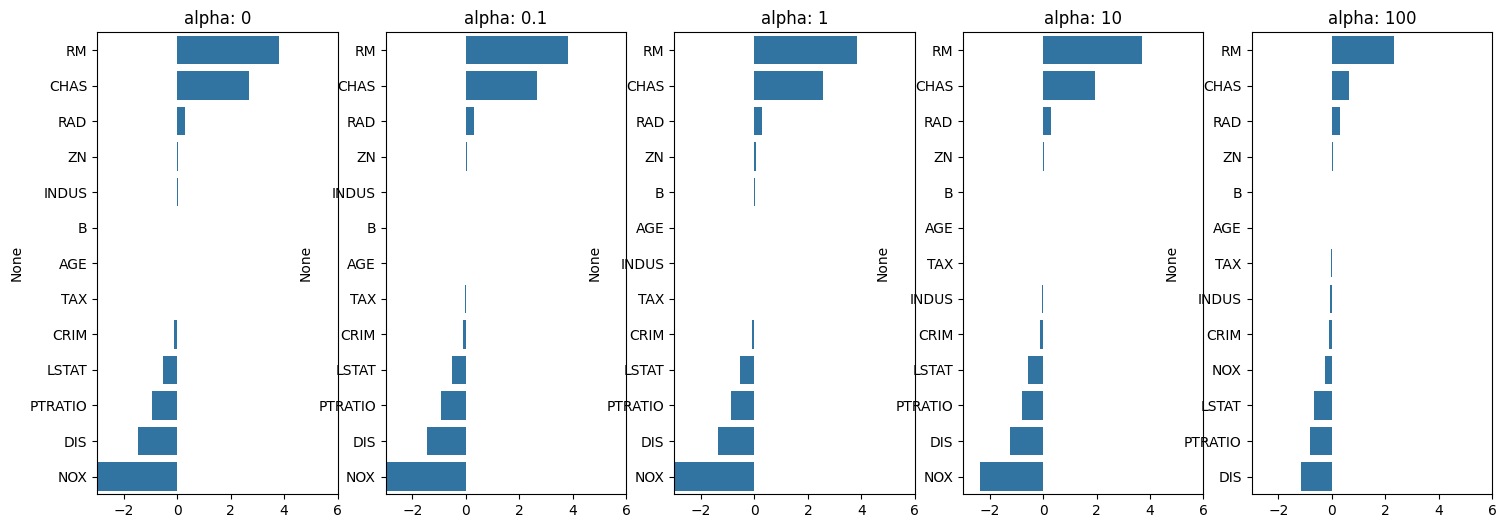

In [9]:
#각 alpha에 따른 회귀계수 값을 시각화하기위해 5개의 열로된 맷플롯립 축 생성
fig,axs=plt.subplots(figsize=(18,6),nrows=1,ncols=5)
#각 alpha에 따른 회귀계수 값을 데이터로 저장하기 위한 dataframe생성
coeff_df=pd.DataFrame()

#alphas 리스트 값을 차례로 입력해 회귀계쑤 값 시각화 및 데이터 저장, pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas) :
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data, y_target)
    #alpha에 따른 피처별로 회귀계수를 series로 변환하고 이를 dataframe 칼럼으로 추가
    coeff=pd.Series(data=ridge.coef_,index=X_data.columns)
    colname='alpha: '+str(alpha)
    coeff_df[colname] = coeff
    #막대 그래프로 각 alpha 값에서의 회귀계수를 시각화,회귀 계수값이 높은순으로 표현
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3, 6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])
#for문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀계수를 dataframe으로 표시
plt.show()

In [10]:
#alpha값 증가에 따른 회귀계수값 변화
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha: '+str(ridge_alphas[0])
#회귀계수 값이 큰 순서대로 정렬
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha: 0,alpha: 0.1,alpha: 1,alpha: 10,alpha: 100
RM,3.809865,3.818233,3.854000,3.702272,2.334536
CHAS,2.686734,2.670019,2.552393,1.952021,0.638335
RAD,0.306049,0.303515,0.290142,0.279596,0.315358
ZN,0.046420,0.046572,0.047443,0.049579,0.054496
INDUS,0.020559,0.015999,-0.008805,-0.042962,-0.052826
B,0.009312,0.009368,0.009673,0.010037,0.009393
AGE,0.000692,-0.000269,-0.005415,-0.010707,0.001212
TAX,-0.012335,-0.012421,-0.012912,-0.013993,-0.015856
CRIM,-0.108011,-0.107474,-0.104595,-0.101435,-0.102202
LSTAT,-0.524758,-0.525966,-0.533343,-0.559366,-0.660764


라쏘 회귀

In [28]:
from sklearn. linear_model import Lasso, ElasticNet

#alpha값에 따른 회귀모델의 폴드 평균 rmse를 출력하고 회귀계수값들을 dataframe으로 반환
def get_linear_reg_eval (model_name, params=None, X_data_n=None, y_target_n=None,verbose=True, return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose : print('#######', model_name, '#######')
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name =='Lasso': model = Lasso(alpha=param)
        elif model_name =='ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n,y_target_n, scoring="neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        #cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 값 추출
        model.fit(X_data_n,y_target_n)
        if return_coeff:
            #alpha에 따른 피처별 회귀계수를 series로 변환하고 이를 dataframe의 칼럼으로 추가
            coeff=pd.Series(data=model.coef_,index=X_data_n.columns)
            colname='alpha:'+str(param)
            coeff_df[colname]=coeff
        return coeff_df

    #end of get_linear_regre_eval

In [25]:
#라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval()함수 호출
lasso_alphas=[0.07,0.1,0.5,1,3]
coeff_lasso_df=get_linear_reg_eval('Lasso',params=lasso_alphas,X_data_n=X_data,y_target_n=y_target)

####### Lasso #######


In [26]:
#alpha값에 따른 피처별 회귀계수
#반환된 coeff_lasso_df를 첫번째 칼럼순으로 내림차순 정렬해 회귀계수 dataframe출력
sort_column='alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column,ascending=False)

,alpha:0.07
RM,3.789725
CHAS,1.434343
RAD,0.270936
ZN,0.049059
B,0.010248
NOX,0.000000
AGE,-0.011706
TAX,-0.014290
INDUS,-0.042120
CRIM,-0.098193


엘라스틱넷 회귀

In [29]:
#엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval()함수 호출
#l1_ratio는 0.7로 고정
elastic_alphas=[0.07,0.1,0.5,1,3]
coeef_elastic_df=get_linear_reg_eval('ElasticNet',params=elastic_alphas,X_data_n=X_data,y_target_n=y_target)

####### ElasticNet #######


In [30]:
#반환된 coeff_elastic_df를 첫번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column='alpha:'+str(elastic_alphas[0])
coeef_elastic_df.sort_values(by=sort_column,ascending=False)

,alpha:0.07
RM,3.574162
CHAS,1.330724
RAD,0.278880
ZN,0.050107
B,0.010122
AGE,-0.010116
TAX,-0.014522
INDUS,-0.044855
CRIM,-0.099468
NOX,-0.175072


In [37]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
#method는 표준 정규 분포 변환(standard) 최댓값,최솟값 정규화,로그변환 결정
#p_degree는 다항식 특성을 추가할때 적용, p_degree는 2이상 부여하지않음
def get_scaled_data(method='None',p_degree=None,input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data
    
    if p_degree != None:
        scaled_data = PolynomialFeatures (degree=p_degree,include_bias=False).fit_transform(scaled_data)

    return scaled_data


In [38]:
#Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출
alphas = [0.1, 1, 10, 100]

#5개 방식으로 변환,먼저 원본 그대로, 표준정규분포, 표준정규 분포+다항식 특성
# 최대/최소 정규화, 최대/최소 정규화+다항식 특성, 로그변환
scale_methods=[(None, None), ('Standard', None), ('Standard', 2),('MinMax', None), ('MinMax', 2), ('Log', None)]
for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1],input_data=X_data)
    print('\n## 변환유형{0}, Polynomial Degree: {1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled,y_target_n=y_target, verbose=False, return_coeff=False)


## 변환유형None, Polynomial Degree: None

## 변환유형Standard, Polynomial Degree: None

## 변환유형Standard, Polynomial Degree: 2

## 변환유형MinMax, Polynomial Degree: None

## 변환유형MinMax, Polynomial Degree: 2

## 변환유형Log, Polynomial Degree: None


로지스틱 회귀

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import load_breast_cancer
from sklearn. linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,roc_auc_score
cancer = load_breast_cancer()

#standardscaler()로 평균이 0, 분산이 1로 데이터 분포도 변환
scaler=StandardScaler()
data_scaled=scaler.fit_transform(cancer.data)

X_train,X_test,y_train,y_test=train_test_split(data_scaled,cancer.target,test_size=0.3,random_state=0)


ImportError: cannot import name 'GridSearchcv' from 'sklearn.model_selection' (/Users/kdi/Desktop/cuai스터디/.conda/lib/python3.11/site-packages/sklearn/model_selection/__init__.py)

In [44]:
#로지스틱 회귀를 이용하여 학습 및 예측 수행
#solver 인자값을 생성자로 입력하지 않으면 solver='lbfgs'
lr_clf=LogisticRegression()
lr_clf.fit(X_train,y_train)
lr_preds=lr_clf.predict(X_test)

#accuracy와 roc_auc 측정
print('accuracy:{0:.3f},roc_auc:{1:.3f}'.format(accuracy_score(y_test,lr_preds),roc_auc_score(y_test,lr_preds)))


accuracy:0.977,roc_auc:0.972


In [46]:
solvers = ['Ibfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
#여러 개의 solver 값별로 logisticregression 학습 후 성능평가
for solver in solvers:
    Ir_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    Ir_preds = lr_clf.predict(X_test)

    #accuracy와 roc_auc 측정
    print('solver:{0},accuracy:{1:.3f},roc_auc:{2:.3f}'.format(solver,accuracy_score(y_test,lr_preds),roc_auc_score(y_test,lr_preds)))

solver:Ibfgs,accuracy:0.977,roc_auc:0.972
solver:liblinear,accuracy:0.977,roc_auc:0.972
solver:newton-cg,accuracy:0.977,roc_auc:0.972
solver:sag,accuracy:0.977,roc_auc:0.972
solver:saga,accuracy:0.977,roc_auc:0.972


In [ ]:
from sklearn.model_selection import GridSearchCV
# solver: 최적화 알고리즘 (작은 데이터는 liblinear, 큰 데이터는 lbfgs 선호)
# C: 규제 강도의 역수 (값이 작을수록 규제가 강함)

params={'solver':['liblinear', 'lbfgs'],'penalty': ['l2','l1'],'C':[0.01,0.1,1,5,10]}
lr_clf = LogisticRegression()
grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3 )
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0},최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_,grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'},최적 평균 정확도:0.979
